<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
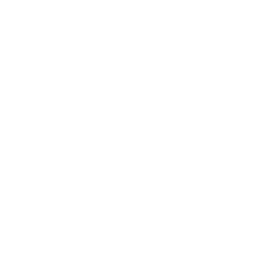
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Profilazione del rischio dei clienti tramite discriminazione canonica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Servizi finanziari / Analisi del rischio di credito &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi esecutiva

Tre gruppi di stato del prestito in un portafoglio di mutui al consumo — **insolventi**, **in corso** ed **estinti anticipatamente** — differiscono simultaneamente lungo diverse dimensioni di salute finanziaria, il che rende qualsiasi singolo rapporto un debole segnale di rischio. Questo notebook applica **PROC CANDISC** (analisi discriminante canonica) a un campione di revisione del rischio di 100 clienti, condensando sei rapporti finanziari correlati in due dimensioni canoniche che massimizzano la separazione tra i tre gruppi di stato.

La prima dimensione canonica racchiude quasi tutta la separazione tra i gruppi — correlazione canonica **0.958**, condividendo il **91.8%** della sua varianza con l'appartenenza al gruppo — e ordina in modo netto i mutuatari, dagli insolventi a un estremo agli estinti anticipatamente all'altro. La seconda dimensione (correlazione canonica **0.503**, al quadrato **0.254**) aggiunge un contrasto secondario guidato dalla storia di morosità e dalla leva finanziaria. Le distanze di Mahalanobis al quadrato confermano che i centroidi **DEFAULT** e **PREPAID** sono la coppia più ampiamente separata (**75.3**), con **CURRENT** che si colloca tra loro (34.3 da DEFAULT, 10.1 da PREPAID). I punteggi canonici risultanti formano un indice di rischio composito compatto, adatto alla segmentazione del portafoglio e alla calibrazione della scorecard.

## Fonti dei dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Rapporti finanziari sintetici dei clienti e metriche comportamentali, etichettati per stato del prestito, estratti come campione bilanciato di revisione del rischio | 100 |

Il campione sovrarappresenta deliberatamente i conti insolventi ed estinti anticipatamente (un'estrazione in stile caso–controllo) affinché ogni gruppo di stato sia abbastanza numeroso da stimare una struttura di covarianza intra-gruppo stabile per l'analisi discriminante.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic loan-customer risk-review sample.
   Three status groups (DEFAULT / CURRENT / PREPAID) are
   over-sampled toward the risk tails so each class is large
   enough for a stable within-group covariance estimate.
   -------------------------------------------------------- */
DATI work.loan_profiles;
    CHIAMARE streaminit(42);
    LUNGHEZZA loan_status $10 vintage $7 customer_id $12;
    VETTORE statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    VETTORE vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    ETICHETTA loan_status='Stato del prestito'
          dti_ratio='Rapporto debito/reddito'
          ltv_ratio='Rapporto prestito/valore'
          payment_to_income='Rapporto rata/reddito'
          credit_utilization='Utilizzo del credito'
          savings_balance='Saldo risparmi'
          months_delinquent='Mesi di morosità'
          vintage='Trimestre di origine'
          customer_id='ID cliente';
    FARE i = 1 FINO_A 20000;
        customer_id = cat('CUST-', PUT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        SE_COND status_prob < 0.30 ALLORA status_idx = 1;       /* DEFAULT */
        ALTRIMENTI SE_COND status_prob < 0.70 ALLORA status_idx = 2;  /* CURRENT */
        ALTRIMENTI status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Financial ratios separate the three status groups */
        SE_COND loan_status = 'DEFAULT' ALLORA FARE;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        FINE;
        ALTRIMENTI SE_COND loan_status = 'CURRENT' ALLORA FARE;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        FINE;
        ALTRIMENTI FARE;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        FINE;
        /* Round and constrain ratios to valid ranges */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        SE_COND dti_ratio < 0.05 ALLORA dti_ratio = 0.05;
        SE_COND dti_ratio > 0.99 ALLORA dti_ratio = 0.99;
        SE_COND ltv_ratio < 0.10 ALLORA ltv_ratio = 0.10;
        SE_COND ltv_ratio > 1.20 ALLORA ltv_ratio = 1.20;
        SE_COND credit_utilization < 0.01 ALLORA credit_utilization = 0.01;
        SE_COND credit_utilization > 0.99 ALLORA credit_utilization = 0.99;
        USCITA;
    FINE;
    RIMUOVERE i status_prob status_idx;
ESEGUIRE;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.25 seconds
  cpu   7.25 seconds


---

### Profili di base dei gruppi

Prima di condensare i rapporti, riassumere come i tre gruppi di stato differiscono una variabile alla volta e confermare la composizione del campione tra le diverse annate di erogazione.

                                                  The MEANS Procedure

                                 Analysis Variable : dti_ratio Rapporto debito/reddito

        Stato del prestito          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        CURRENT                        46          0.331          0.112
        DEFAULT                        29          0.570          0.114
        PREPAID                        25          0.216          0.056
        ---------------------------------------------------------------

                                 Analysis Variable : ltv_ratio Rapporto prestito/valore

        Stato del prestito          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        CURRENT                        46          0.776          0.080
        DEFAULT                        29          0.914          0.103
        PREPAID                


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


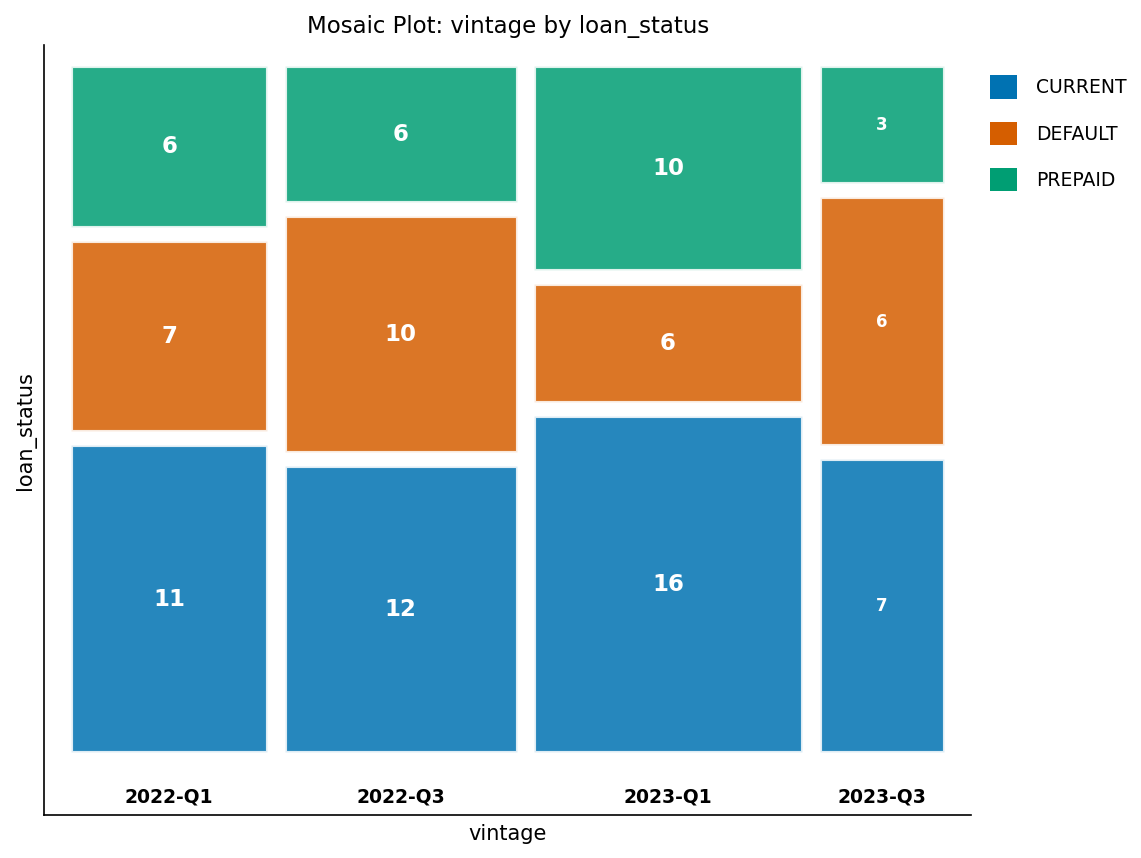

In [2]:
/* --------------------------------------------------------
   Baseline financial-ratio distributions by loan status
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.loan_profiles n mean std maxdec=3;
    CLASSE loan_status;
    VARIABILE dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
ESEGUIRE;

/* --------------------------------------------------------
   Sample composition by vintage and status
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
ESEGUIRE;

---

### Analisi discriminante canonica

Adatta un unico modello discriminante canonico aggregato su tutti i 100 clienti. `OUT=` scrive i punteggi canonici per ciascun cliente, `OUTSTAT=` cattura la struttura canonica, i centroidi delle classi e le distanze di Mahalanobis al quadrato, e `DISTANCE` richiede le distanze tra i gruppi. La procedura pubblicizzata qui è esattamente quella che viene eseguita: **PROC CANDISC**.


NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

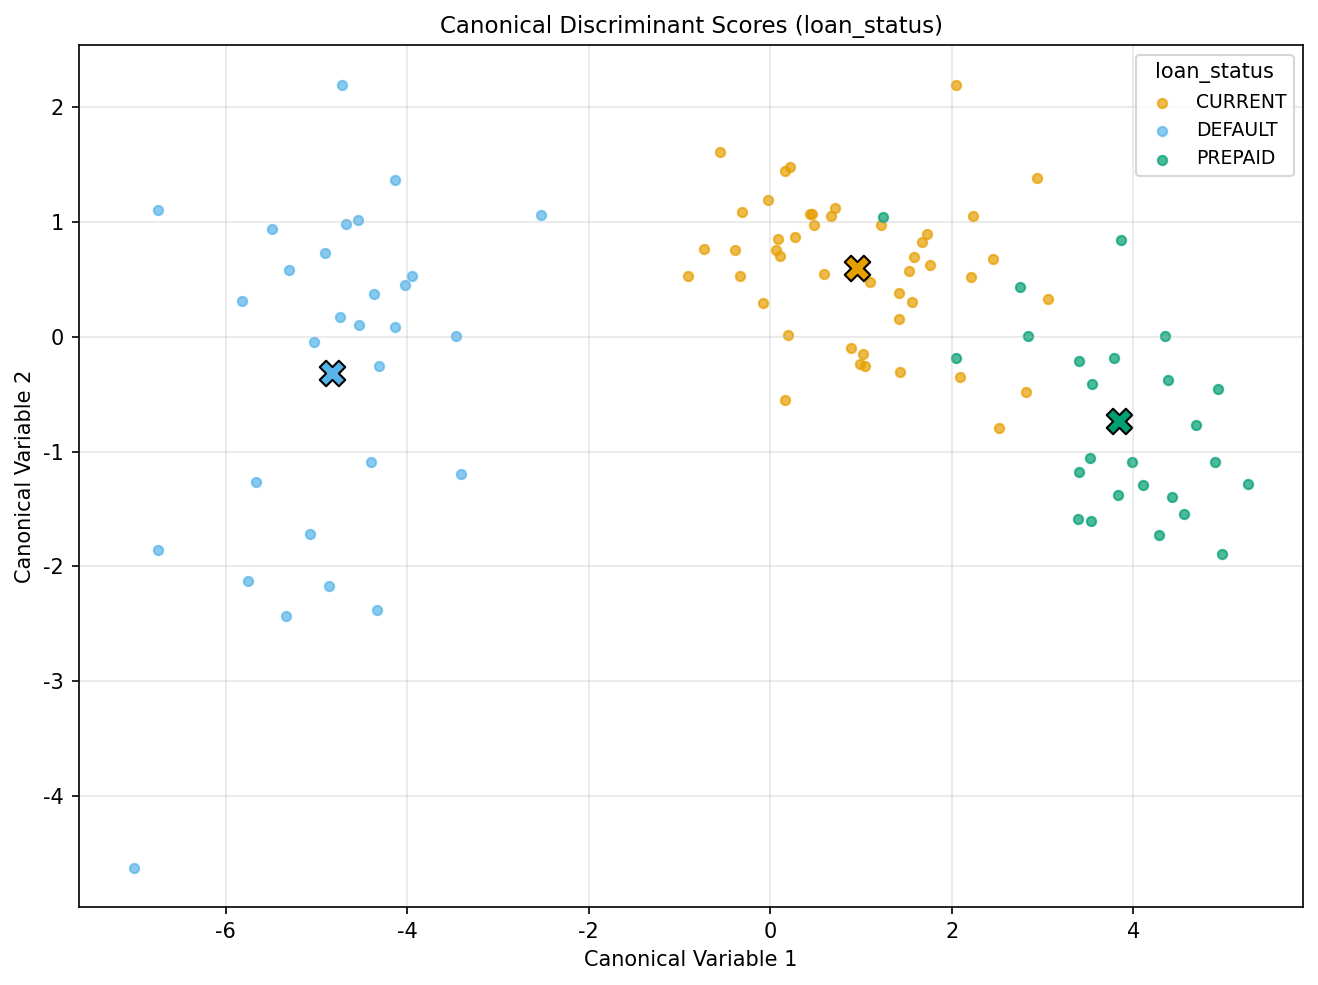

In [3]:
/* --------------------------------------------------------
   Canonical discriminant analysis of loan-status groups.
   OUT=    per-customer canonical scores (Can1, Can2)
   OUTSTAT= structure, class means, Mahalanobis distances
   -------------------------------------------------------- */
ODS USCITA CanonicalCorrelations=work.can_corr;

PROCEDURA CANDISC DATI=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    CLASSE loan_status;
    VARIABILE dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    TITOLO 'Discriminazione canonica del rischio per gruppi di stato del prestito';
ESEGUIRE;

ODS USCITA CLOSE;

---

### Correlazioni canoniche

Quanta parte della separazione tra i tre gruppi cattura ciascuna dimensione canonica.

In [4]:
PROCEDURA STAMPARE DATI=work.can_corr noobs;
    TITOLO 'Correlazioni canoniche';
ESEGUIRE;

                                                 Correlazioni canoniche                                                 

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Struttura canonica (loading delle variabili)

La correlazione di ciascun rapporto finanziario originale con le due dimensioni canoniche — è così che le dimensioni vengono interpretate.

In [5]:
PROCEDURA STAMPARE DATI=work.can_stat noobs;
    DOVE _type_ = 'STRUCTUR';
    VARIABILE _name_ Can1 Can2;
    TITOLO 'Struttura canonica intra-classe aggregata';
ESEGUIRE;

                                       Struttura canonica intra-classe aggregata                                        

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Centroidi dei gruppi e distanze di Mahalanobis

Le medie delle classi sugli assi canonici (i centroidi dei gruppi) e le distanze di Mahalanobis al quadrato tra ogni coppia di gruppi — la base per la calibrazione del punteggio di rischio.

In [6]:
PROCEDURA STAMPARE DATI=work.can_stat noobs;
    DOVE _type_ IN ('CANMEAN' 'DIST');
    VARIABILE _type_ _name_ Can1 Can2;
    TITOLO 'Centroidi di gruppo (CANMEAN) e distanze di Mahalanobis al quadrato (DIST)';
ESEGUIRE;

                       Centroidi di gruppo (CANMEAN) e distanze di Mahalanobis al quadrato (DIST)                       

 _TYPE_              _NAME_       CAN1       CAN2
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Mappa discriminante canonica

Ogni cliente rappresentato nello spazio canonico bidimensionale, colorato per stato del prestito. Cluster ben separati indicano che i punteggi canonici trasportano forti informazioni sul gruppo.

                       Centroidi di gruppo (CANMEAN) e distanze di Mahalanobis al quadrato (DIST)                       




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


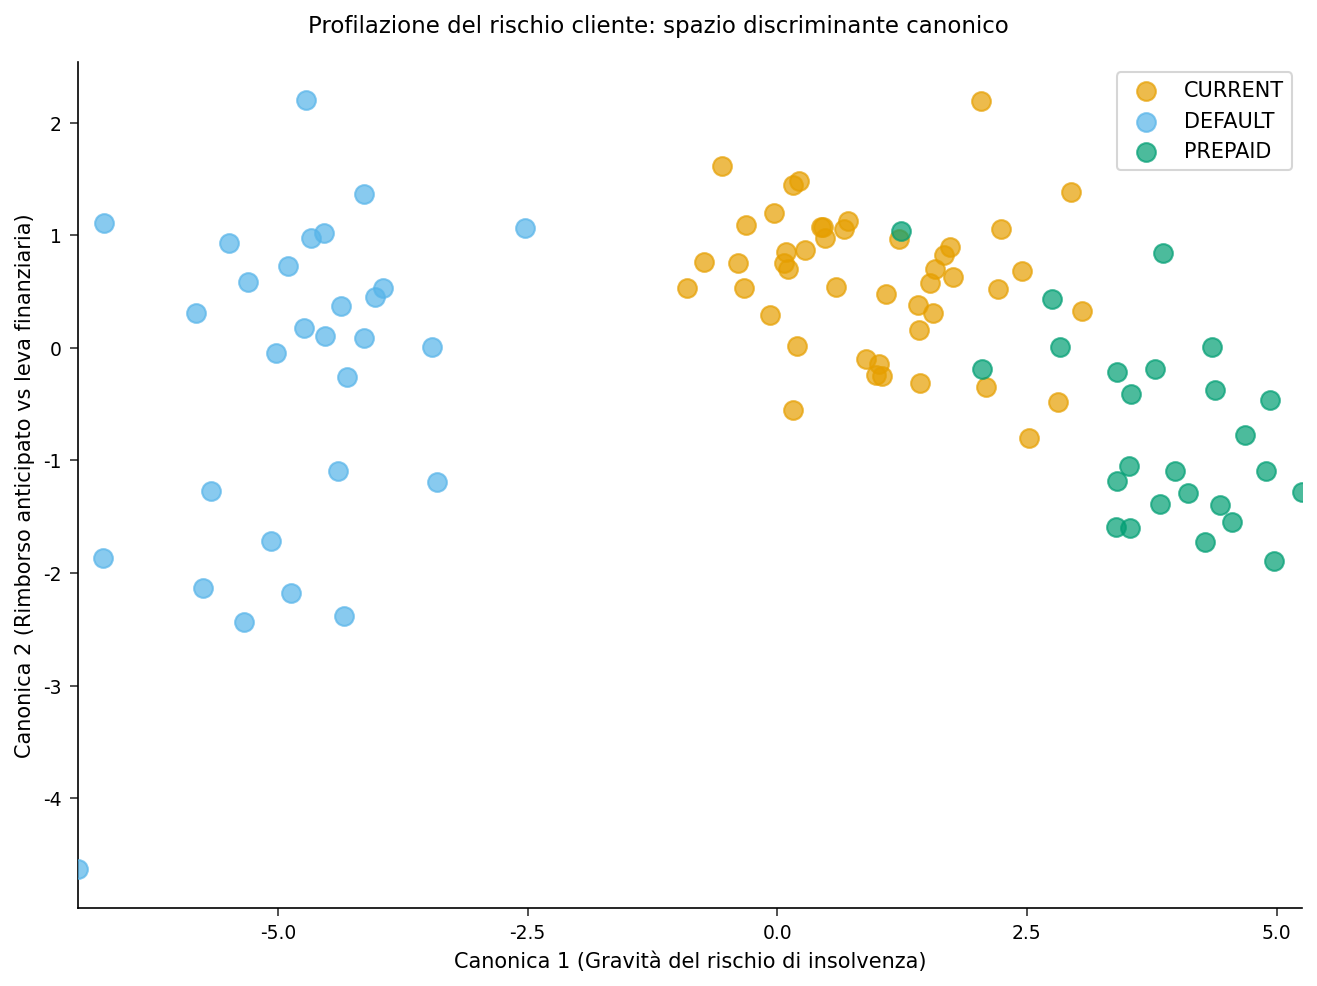

In [7]:
PROCEDURA SGPLOT DATI=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS ETICHETTA='Canonica 1 (Gravità del rischio di insolvenza)';
    YAXIS ETICHETTA='Canonica 2 (Rimborso anticipato vs leva finanziaria)';
    TITOLO 'Profilazione del rischio cliente: spazio discriminante canonico';
ESEGUIRE;

---

### Interpretazione

Le due dimensioni canoniche separano nettamente i tre gruppi di stato del prestito all'interno di questo campione di 100 clienti (46 in corso, 29 insolventi, 25 estinti anticipatamente).

**Dimensione 1 — gravità del rischio di insolvenza (correlazione canonica 0.958, 91.8% di varianza condivisa).** Questo asse da solo spiega la stragrande maggioranza della separazione tra i gruppi (autovalore 11.20 contro 0.34 per il secondo asse). Nella struttura canonica intra-classe aggregata carica più fortemente sull'utilizzo del credito (-0.595), sul rapporto debito/reddito (-0.404), sull'LTV (-0.370), sui mesi di morosità (-0.324) e sul rapporto pagamento/reddito (-0.304) — ogni misura di leva e di onere punta nella stessa direzione. Poiché i loading sono negativi, punteggi Can1 bassi (più negativi) contrassegnano i mutuatari a più alto rischio. I centroidi delle classi lo confermano: i conti insolventi si collocano a Can1 = -4.83, i conti in corso a +0.96 e i conti estinti anticipatamente a +3.84, un ordinamento monotono netto dalla peggiore alla migliore salute creditizia.

**Dimensione 2 — leva finanziaria contro morosità (correlazione canonica 0.503).** Il secondo asse contrappone il rapporto LTV (+0.733) ai mesi di morosità (-0.700): separa i mutuatari altamente indebitati ma in regola da quelli che presentano morosità. Affina il quadro all'interno di Can1 ma contribuisce a una separazione molto minore, come mostrano i centroidi Can2 quasi uguali per i gruppi performanti (in corso +0.599, estinti anticipatamente -0.736).

**Separazione tra i gruppi.** Le distanze di Mahalanobis al quadrato tra le medie delle classi quantificano gli scarti: DEFAULT-PREPAID è la più grande a 75.3, DEFAULT-CURRENT è 34.3 e CURRENT-PREPAID è la più piccola a 10.1. I due gruppi performanti sono quindi più vicini tra loro di quanto ciascuno lo sia al gruppo insolvente, esattamente come un istituto di credito si aspetterebbe.

**Uso pratico.** Il primo punteggio canonico si comporta come un indice di rischio composito già pronto: comprime sei rapporti correlati in un'unica dimensione ben separata che ordina i clienti dal più alto al più basso rischio di insolvenza. I team di portafoglio possono segmentare sui punti di taglio di Can1, e le distanze di Mahalanobis forniscono una base di principio per assegnare un nuovo richiedente al gruppo di stato più vicino durante la calibrazione della scorecard.

---

### Esportazione per il motore di scoring

Rende persistenti i punteggi canonici per ciascun cliente e il dataset delle statistiche canoniche (che contiene i centroidi e le distanze di Mahalanobis) per la successiva calibrazione della scorecard.

In [8]:
/* --------------------------------------------------------
   Export canonical risk scores and canonical statistics
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnologia di <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>